In [1]:
import os
import json
import pandas as pd
import seaborn as sns
import yaml

In [2]:
wandb_dir = "/scratch/nia4240/compute-better_spent-scratch/wandb"

In [4]:
rows = []
for folder in os.listdir(wandb_dir):
    if folder.startswith("run-") and os.path.isdir(os.path.join(wandb_dir, folder)):
        summary_path = os.path.join(wandb_dir, folder, 'files/wandb-summary.json')
        config_path = os.path.join(wandb_dir, folder, 'files/config.yaml')
        
        if os.path.exists(summary_path):
            with open(summary_path, 'r') as f:
                summary_data = json.load(f)

        if os.path.exists(config_path):
            with open(config_path, 'r') as f:
                config_data = yaml.safe_load(f)
        
        config_clean = {k: v['value'] for k, v in config_data.items() if k != 'wandb_version'}
        rows.append({**config_clean, **summary_data})

df = pd.DataFrame(rows)

In [5]:
# drop rows for which the column 'run_name' is not 'muP_test' or 'muP_test_noQKnorm'
df['run_name_prefix'] = df['run_name'].str.split('/').str[0]
# df = df[df['run_name_prefix'].isin(['muP_test', 'muP_test_noQKnorm', 'BTT_muP_test'])]
df = df[df['run_name_prefix'].isin(['BTTvsLR3'])]
df['condition'] = df.apply(lambda x: (x['run_name_prefix'], x['alt_attn_config'][:15]), axis=1)

In [6]:
df.groupby(['run_name_prefix', 'alt_attn_config', 'scale_factor'])['run_name'].count()

run_name_prefix  alt_attn_config                                                                                              scale_factor
BTTvsLR3         BBTT,2,1,False                                                                                               1.0             1
                                                                                                                              2.0             1
                                                                                                                              4.0             1
                                                                                                                              8.0             1
                                                                                                                              16.0            1
                                                                                                                              32.0           

<Axes: xlabel='lr', ylabel='test_loss'>

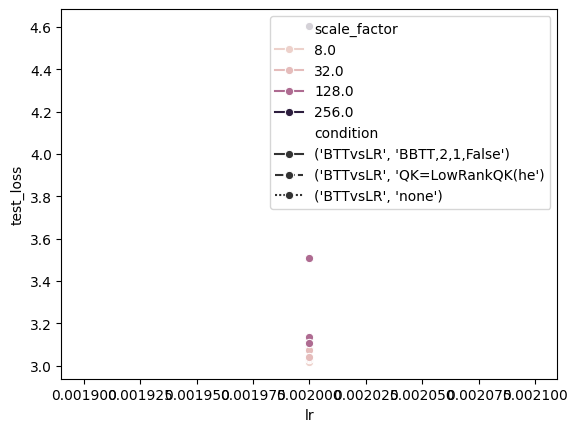

In [6]:
sns.lineplot(x='lr', y='test_loss', hue='scale_factor', style='condition', data=df, marker='o')

In [13]:
list(df)

['data_path',
 'dataset',
 'resolution',
 'crop_resolution',
 'n_train',
 'ar_modeling',
 'max_freq',
 'min_freq',
 'input_dim',
 'use_bias',
 'shuffle_pixels',
 'model',
 'num_ffn_experts',
 'width',
 'scale_factor',
 'depth',
 'heads',
 'dim_head',
 'ffn_expansion',
 'patch_size',
 'in_channels',
 'emb_mult',
 'attn_mult',
 'output_mult',
 'fact',
 'int_pow',
 'layer_norm',
 'expr',
 'init_type',
 'alt_attn_config',
 'cores_n',
 'use_wrong_mult',
 'init_method',
 'init_mult_1',
 'init_mult_2',
 'lr_mult_1',
 'lr_mult_2',
 'input_lr_mult',
 'init_mult',
 'struct',
 'layers',
 'rank_frac',
 'tt_rank',
 'tt_cores',
 'num_blocks',
 'aux_loss_weight',
 'spec_penalty_weight',
 'seed',
 'optimizer',
 'batch_size',
 'accum_steps',
 'lr',
 'warmup_epochs',
 'scheduler',
 'weight_decay',
 'epochs',
 'smooth',
 'clip',
 'reload',
 'augment',
 'mixup',
 'maximum_steps',
 'calculate_stats',
 'checkpoint_folder',
 'save_freq',
 'save',
 'wandb',
 'wandb_project',
 'wandb_entity',
 'run_name',
 'nu

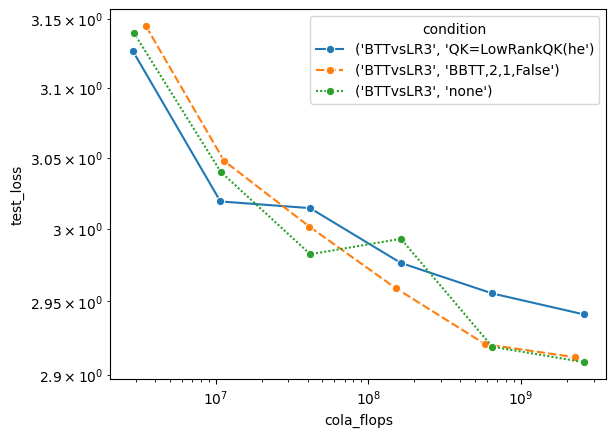

In [14]:
import matplotlib.pyplot as plt
sns.lineplot(x='cola_flops', y='test_loss', hue='condition', style='condition', data=df, marker='o')
plt.xscale('log')
plt.yscale('log')